**INSTALL LIBRARIES**

In [ ]:
!pip install tensorflow scikit-learn seaborn matplotlib -q

**IMPORT LIBRARIES**

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

from google.colab import drive

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.20.0
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**MOUNT GOOGLE DRIVE**

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**GLOBAL CONFIGURATION**

In [ ]:
# ==========================================================
# PATH CONFIGURATION
# ==========================================================

BASE_PATH = '/content/drive/MyDrive/Dataset Project Deep Learning'

RAW_DATASET = os.path.join(BASE_PATH, 'Dataset Mentah')

SPLIT_DATASET = os.path.join(BASE_PATH, 'Dataset Split')

MODEL_SAVE_PATH = os.path.join(BASE_PATH, 'Models')

# ==========================================================
# HYPERPARAMETER
# ==========================================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

EPOCHS_MOBILENET = 25

EPOCHS_DCNN = 40

CLASS_NAMES = [
    'Daun Kering',
    'Daun Sehat'
]

# ==========================================================
# CREATE DIRECTORY
# ==========================================================

os.makedirs(SPLIT_DATASET, exist_ok=True)

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("✅ Configuration Loaded")

✅ Configuration Loaded


**RANDOM SPLIT DATASET**

In [ ]:
random.seed(SEED)

SPLITS = {
    'train': 0.70,
    'val': 0.15,
    'test': 0.15
}

# ==========================================================
# CREATE SPLIT FOLDER
# ==========================================================

for split_name in SPLITS.keys():

    for class_name in CLASS_NAMES:

        os.makedirs(
            os.path.join(
                SPLIT_DATASET,
                split_name,
                class_name
            ),
            exist_ok=True
        )

# ==========================================================
# RANDOM SPLIT
# ==========================================================

for class_name in CLASS_NAMES:

    source_dir = os.path.join(
        RAW_DATASET,
        class_name
    )

    images = os.listdir(source_dir)

    random.shuffle(images)

    total_images = len(images)

    train_end = int(total_images * SPLITS['train'])

    val_end = train_end + int(
        total_images * SPLITS['val']
    )

    train_images = images[:train_end]

    val_images = images[train_end:val_end]

    test_images = images[val_end:]

    split_map = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for split_name, split_images in split_map.items():

        for image_name in split_images:

            src = os.path.join(
                source_dir,
                image_name
            )

            dst = os.path.join(
                SPLIT_DATASET,
                split_name,
                class_name,
                image_name
            )

            shutil.copy2(src, dst)

print("✅ Dataset Split Finished")

✅ Dataset Split Finished


**LOAD DATASET**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED
)

print("\nDetected Classes :")

print(train_ds.class_names)

Found 1016 files belonging to 2 classes.
Found 217 files belonging to 2 classes.
Found 220 files belonging to 2 classes.

Detected Classes :
['Daun Kering', 'Daun Sehat']


**DATA PIPELINE OPTIMIZATION**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("✅ Dataset Optimized")

✅ Dataset Optimized


In [ ]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Dataset Deep Learning",
    image_size=(224,224),
    batch_size=32
)

print(temp_ds.class_names)

Found 434 files belonging to 2 classes.
['Daun Kering', 'Daun Sehat']


**VISUALIZE DATASET**

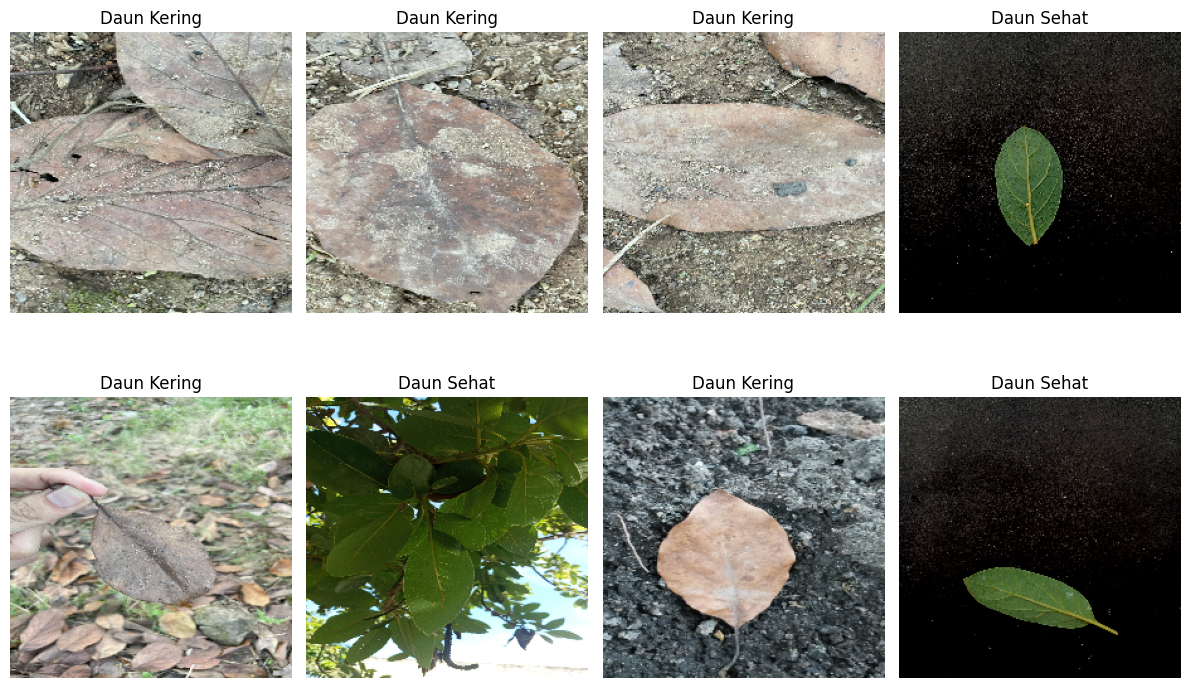

In [ ]:
plt.figure(figsize=(12,8))

for images, labels in train_ds.take(1):

    for i in range(8):

        ax = plt.subplot(2,4,i+1)

        plt.imshow(
            images[i].numpy().astype('uint8')
        )

        label_idx = np.argmax(labels[i])

        plt.title(
            CLASS_NAMES[label_idx]
        )

        plt.axis('off')

plt.tight_layout()

plt.show()

**REALISTIC AUGMENTATION**

In [ ]:
data_augmentation = keras.Sequential([

    layers.RandomFlip('horizontal'),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )

], name='realistic_augmentation')

print("✅ Realistic Augmentation Ready")

✅ Realistic Augmentation Ready


**CLASS WEIGHT (ANTI BIAS)**

In [ ]:
labels_list = []

for _, labels in train_ds.unbatch():

    labels_list.append(
        np.argmax(labels.numpy())
    )

labels_array = np.array(labels_list)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)

class_weight_dict = {

    i: class_weights[i]

    for i in range(len(class_weights))
}

print("✅ Class Weight")

print(class_weight_dict)

✅ Class Weight
{0: np.float64(0.7685325264750378), 1: np.float64(1.4309859154929578)}


**FOCAL LOSS**

In [ ]:
import tensorflow.keras.backend as K

def categorical_focal_loss(
    gamma=2.0,
    alpha=0.25
):

    def focal_loss(y_true, y_pred):

        epsilon = K.epsilon()

        y_pred = K.clip(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        cross_entropy = -y_true * K.log(y_pred)

        weight = alpha * K.pow(
            1 - y_pred,
            gamma
        )

        loss = weight * cross_entropy

        return K.sum(loss, axis=1)

    return focal_loss

print("✅ Focal Loss Ready")

✅ Focal Loss Ready


**MOBILE NET V2 (BEST MODEL)**

In [ ]:
NUM_CLASSES = len(CLASS_NAMES)

# ==========================================================
# BASE MODEL
# ==========================================================

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# ==========================================================
# FINE TUNING
# ==========================================================

base_model.trainable = True

# Freeze sebagian layer awal
for layer in base_model.layers[:-30]:
    layer.trainable = False

# ==========================================================
# BUILD MODEL
# ==========================================================

inputs = keras.Input(
    shape=(224, 224, 3)
)

# Data augmentation
x = data_augmentation(inputs)

# ==========================================================
# PREPROCESS INPUT (FIX ERROR)
# ==========================================================

# JANGAN pakai:
# x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Ganti manual agar tidak muncul:
# "Only input tensors may be passed as positional arguments"

x = layers.Rescaling(
    scale=1./127.5,
    offset=-1
)(x)

# ==========================================================
# MOBILENET
# ==========================================================

x = base_model(
    x,
    training=False
)

# ==========================================================
# CLASSIFIER HEAD
# ==========================================================

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

# ==========================================================
# FINAL MODEL
# ==========================================================

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="Leaf_MobileNetV2"
)

mobilenet_model.summary()

Model: "Leaf_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ realistic_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

**COMPILE MOBILE NET**

In [ ]:
mobilenet_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=categorical_focal_loss(),

    metrics=['accuracy']
)

print("✅ MobileNetV2 Compiled")

✅ MobileNetV2 Compiled


**CALLBACKS**

In [ ]:
callbacks = [

    keras.callbacks.EarlyStopping(

        monitor='val_loss',

        patience=5,

        restore_best_weights=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=2,

        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(

        filepath=f'{MODEL_SAVE_PATH}/best_mobilenet.h5',

        monitor='val_accuracy',

        save_best_only=True,

        verbose=1
    )
]

print("✅ Callbacks Ready")

✅ Callbacks Ready


**TRAIN MOBILE NET V2**

In [ ]:
history_mobilenet = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_MOBILENET,

    class_weight=class_weight_dict,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7141 - loss: 0.1165
Epoch 1: val_accuracy improved from None to 0.97235, saving model to /content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 227ms/step - accuracy: 0.7933 - loss: 0.0559 - val_accuracy: 0.9724 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9423 - loss: 0.0152
Epoch 2: val_accuracy improved from 0.97235 to 0.99539, saving model to /content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9498 - loss: 0.0113 - val_accuracy: 0.9954 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9675 - loss: 0.0069
Epoch 3: val_accuracy did not improve from 0.99539
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9783 - loss: 0.0061 - val_accuracy: 0.9908 - val_loss: 0.0016 - learning_rate: 1.0000e-04
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9745 - loss: 0.0038
Epoch 4: val_accuracy did not improve from 0.99539
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9783 - loss: 0.0037 - val_accuracy: 0.9954 - val_loss: 0.0017 - learning_rate: 1.0000e-04
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9853 - loss: 0.0025
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 5: val_accurac

**DCNN MODEL**

In [ ]:
dcnn_model = keras.Sequential([

    keras.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Rescaling(1./255),

    # ======================================================
    # BLOCK 1
    # ======================================================

    layers.Conv2D(
        32,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    # ======================================================
    # BLOCK 2
    # ======================================================

    layers.Conv2D(
        64,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    # ======================================================
    # BLOCK 3
    # ======================================================

    layers.Conv2D(
        128,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    # ======================================================
    # BLOCK 4
    # ======================================================

    layers.Conv2D(
        256,
        3,
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    # ======================================================
    # CLASSIFIER
    # ======================================================

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )

], name='Leaf_DCNN')

dcnn_model.summary()

Model: "Leaf_DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ realistic_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

**COMPILE DCNN**

In [ ]:
dcnn_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=categorical_focal_loss(),

    metrics=['accuracy']
)

print("✅ DCNN Compiled")

✅ DCNN Compiled


**TRAIN DCNN**

In [ ]:
history_dcnn = dcnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_DCNN,

    class_weight=class_weight_dict,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7264 - loss: 0.0883
Epoch 1: val_accuracy did not improve from 0.99539
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.7874 - loss: 0.0710 - val_accuracy: 0.3502 - val_loss: 0.0444 - learning_rate: 1.0000e-04
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8434 - loss: 0.0452
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_accuracy did not improve from 0.99539
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.8533 - loss: 0.0473 - val_accuracy: 0.3502 - val_loss: 0.0481 - learning_rate: 1.0000e-04
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8762 - loss: 0.0298
Epoch 3: val_accuracy did not improve from 0.99539
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.8819 - loss: 0.0348 - val_accuracy: 0.3502 - val_loss: 0.0687 - learning_rate: 5.0000e-05
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8956 - loss

**PLOT TRAINING HISTORY**

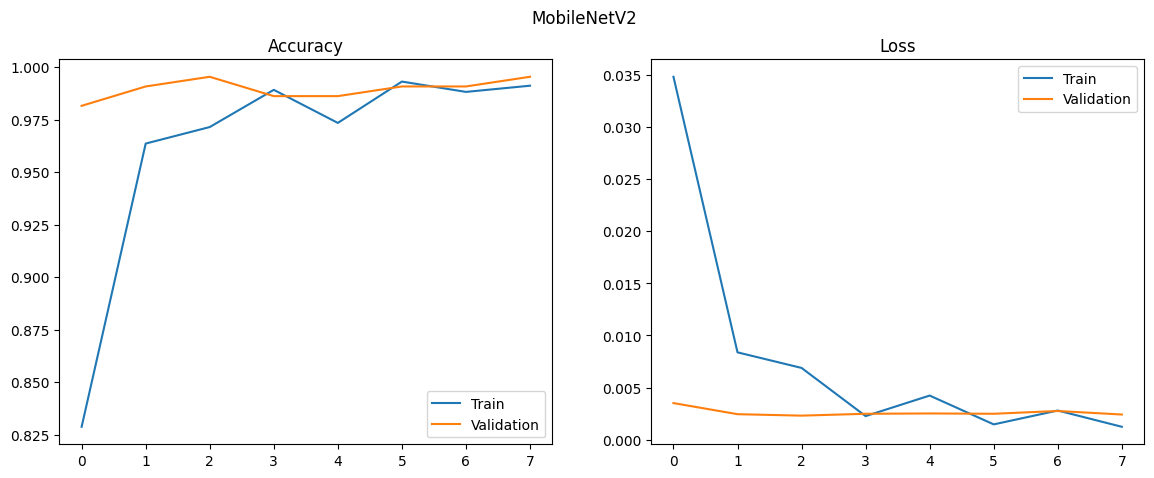

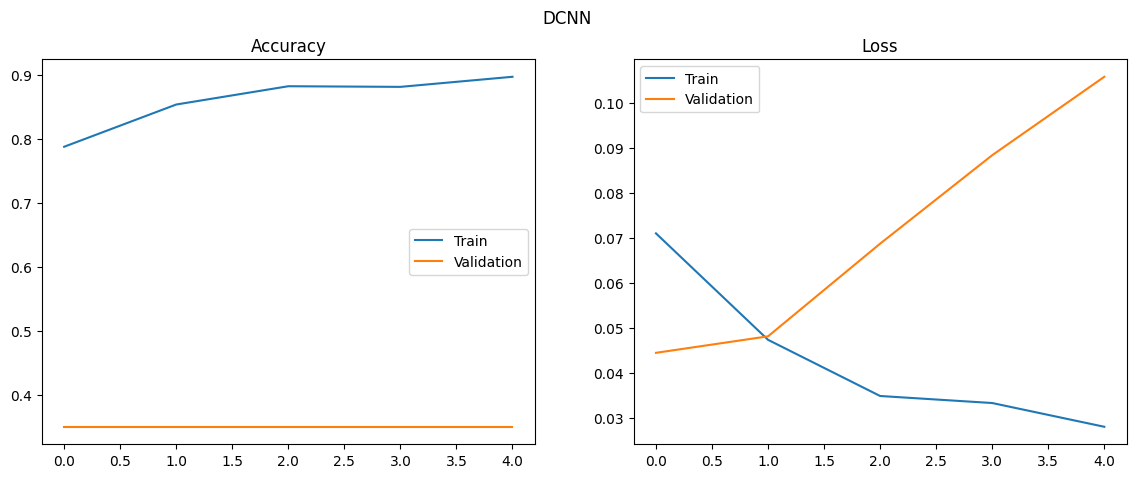

In [ ]:
def plot_history(history, title):

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    # ======================================================
    # ACCURACY
    # ======================================================

    ax[0].plot(
        history.history['accuracy']
    )

    ax[0].plot(
        history.history['val_accuracy']
    )

    ax[0].set_title('Accuracy')

    ax[0].legend([
        'Train',
        'Validation'
    ])

    # ======================================================
    # LOSS
    # ======================================================

    ax[1].plot(
        history.history['loss']
    )

    ax[1].plot(
        history.history['val_loss']
    )

    ax[1].set_title('Loss')

    ax[1].legend([
        'Train',
        'Validation'
    ])

    plt.suptitle(title)

    plt.show()

plot_history(
    history_mobilenet,
    'MobileNetV2'
)

plot_history(
    history_dcnn,
    'DCNN'
)

**EVALUATION FUNCTION**

In [ ]:
def evaluate_model(
    model,
    dataset,
    class_names,
    model_name
):

    y_true = []

    y_pred = []

    # ======================================================
    # PREDICTION
    # ======================================================

    for images, labels in dataset:

        preds = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            np.argmax(
                labels.numpy(),
                axis=1
            )
        )

        y_pred.extend(
            np.argmax(
                preds,
                axis=1
            )
        )

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    # ======================================================
    # ACCURACY
    # ======================================================

    accuracy = np.mean(
        y_true == y_pred
    )

    print(f'\n🎯 Accuracy : {accuracy*100:.2f}%')

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f'Confusion Matrix - {model_name}'
    )

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================

    print('\n📋 Classification Report\n')

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

**EVALUATE MODELS**


🎯 Accuracy : 97.73%


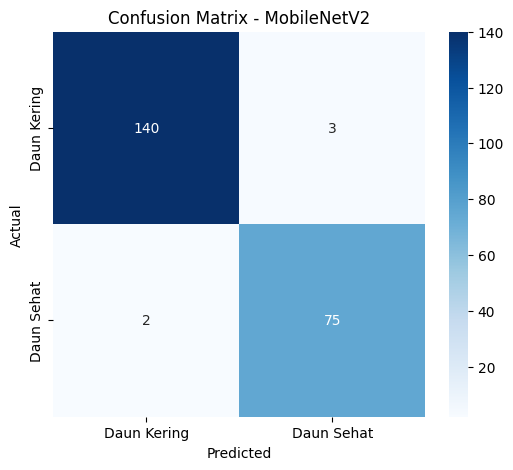


📋 Classification Report

              precision    recall  f1-score   support

 Daun Kering       0.99      0.98      0.98       143
  Daun Sehat       0.96      0.97      0.97        77

    accuracy                           0.98       220
   macro avg       0.97      0.98      0.98       220
weighted avg       0.98      0.98      0.98       220




🎯 Accuracy : 35.00%


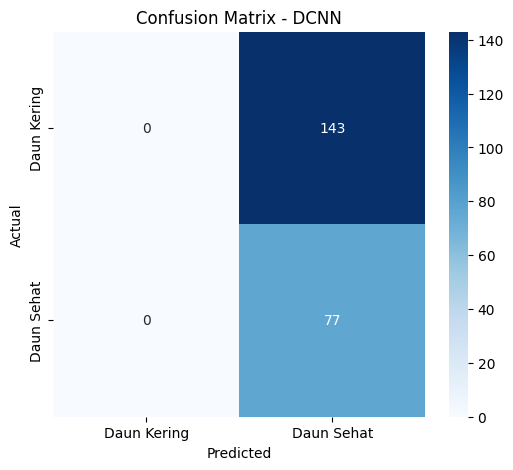


📋 Classification Report

              precision    recall  f1-score   support

 Daun Kering       0.00      0.00      0.00       143
  Daun Sehat       0.35      1.00      0.52        77

    accuracy                           0.35       220
   macro avg       0.17      0.50      0.26       220
weighted avg       0.12      0.35      0.18       220



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
evaluate_model(

    mobilenet_model,

    test_ds,

    CLASS_NAMES,

    'MobileNetV2'
)

evaluate_model(

    dcnn_model,

    test_ds,

    CLASS_NAMES,

    'DCNN'
)

**SAVE MODEL (H5 STABLE)**

In [ ]:
mobilenet_model.save(
    f'{MODEL_SAVE_PATH}/mobilenet_model.h5'
)

dcnn_model.save(
    f'{MODEL_SAVE_PATH}/dcnn_model.h5'
)

print("✅ H5 Saved Successfully")

✅ H5 Saved Successfully


**TEST SINGLE IMAGE**

In [ ]:
def predict_image(
    model,
    image_path,
    model_type='mobilenet'
):

    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # ======================================================
    # PREPROCESSING
    # ======================================================

    if model_type == 'mobilenet':

        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(
            img_array
        )

    else:

        img_array = img_array / 255.0

    # ======================================================
    # PREDICT
    # ======================================================

    prediction = model.predict(
        img_array,
        verbose=0
    )[0]

    class_idx = np.argmax(prediction)

    confidence = prediction[class_idx] * 100

    # ======================================================
    # VISUALIZATION
    # ======================================================

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.axis('off')

    plt.title(
        f'{CLASS_NAMES[class_idx]}\n{confidence:.2f}%'
    )

    plt.show()

    print("Prediction :", CLASS_NAMES[class_idx])

    print("Confidence :", confidence)

In [ ]:
from google.colab import files

files.download("best_mobilenet.h5")
files.download("dcnn_model.h5")

FileNotFoundError: Cannot find file: best_mobilenet.h5

In [ ]:
import os

drive_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(drive_path):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Dataset Deep Learning/mobilenet_model.h5
/content/drive/MyDrive/Dataset Deep Learning/mobilenet_clean.h5
/content/drive/MyDrive/Dataset Deep Learning/dcnn_clean.h5
/content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5
/content/drive/MyDrive/Dataset Project Deep Learning/Models/mobilenet_model.h5
/content/drive/MyDrive/Dataset Project Deep Learning/Models/dcnn_model.h5
/content/drive/MyDrive/Leaf Models/best_mobilenet.h5


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/Dataset Project Deep Learning/Models/best_mobilenet.h5")

files.download("/content/drive/MyDrive/Dataset Project Deep Learning/Models/dcnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(train_ds.class_names)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [ ]:
for images, labels in train_ds.take(1):

    print(labels.numpy()[:10])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


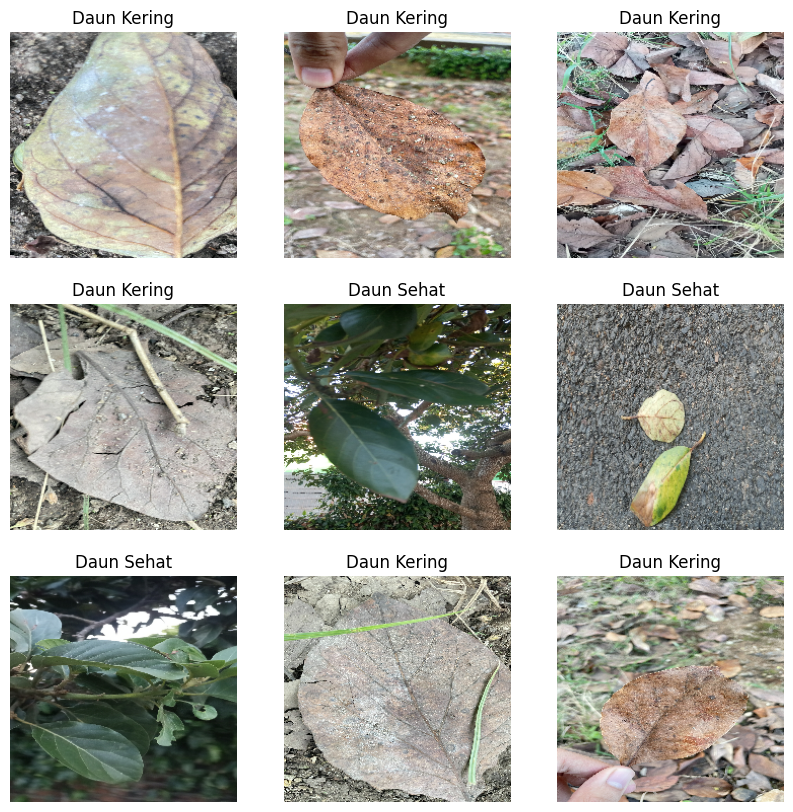

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Daun Kering', 'Daun Sehat']

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = np.argmax(labels[i])

        plt.title(class_names[label_index])

        plt.axis("off")

plt.show()